<a href="https://colab.research.google.com/github/Pri-codes-10/Kaggle_housing_competition/blob/main/HAHAH34.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


def seed_everything(seed):
    np.random.seed(seed)

seed_everything(42)

In [ ]:
!pip install tabpfn


In [ ]:
import os

# 1. Set your TabPFN API Token
os.environ["TABPFN_TOKEN"] = "Your API Key"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

display(df_train.head())
display(df_train.info())
display(df_test.head())
display(df_test.info())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

None

In [ ]:
missing_train_percentage = df_train.isnull().mean() * 100
missing_test_percentage = df_test.isnull().mean() * 100

print("Missing Value Percentage in Train Data:")
print(missing_train_percentage.sort_values(ascending=False))
print("\nMissing Value Percentage in Test Data:")
print(missing_test_percentage.sort_values(ascending=False))

Missing Value Percentage in Train Data:
PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

Missing Value Percentage in Test Data:
PoolQC           99.794380
MiscFeature      96.504455
Alley            92.666210
Fence            80.123372
MasVnrType       61.274846
                   ...    
EnclosedPorch     0.000000
MiscVal           0.000000
MoSold            0.000000
YrSold            0.000000
SaleCondition     0.000000
Length: 80, dtype: float64


<Axes: >

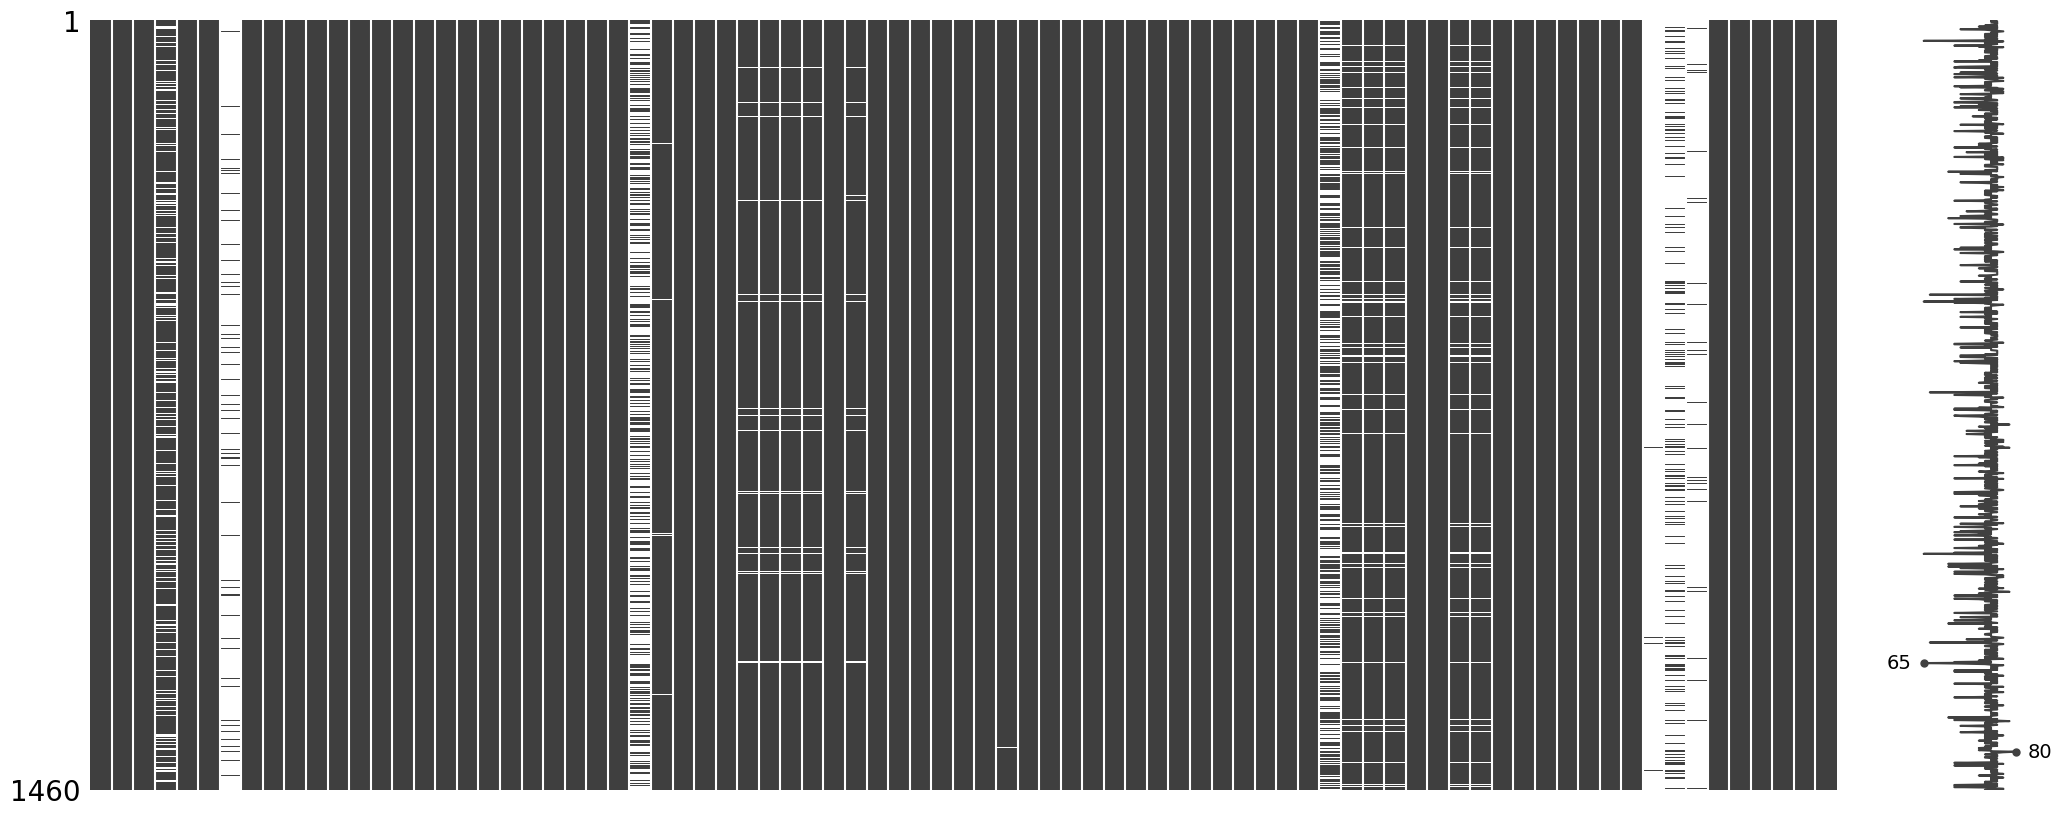

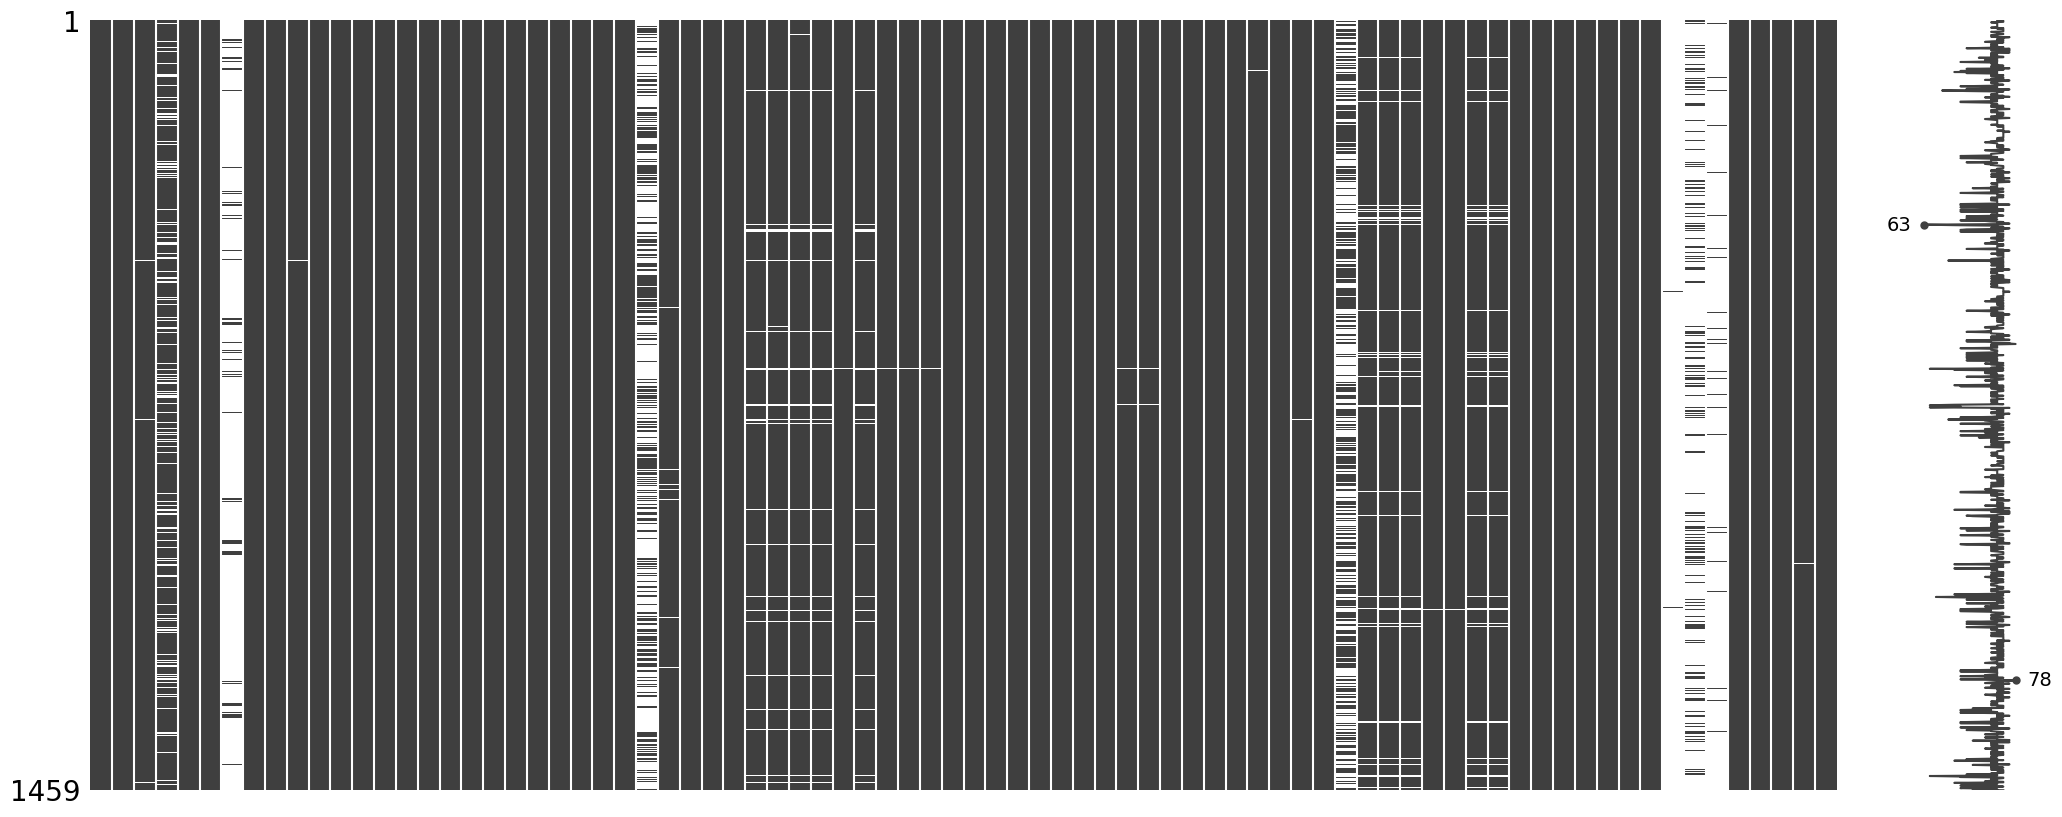

In [ ]:
import missingno as msno
msno.matrix(df_train)
msno.matrix(df_test)

In [ ]:
threshold = 10

cols_to_drop_train = missing_train_percentage[missing_train_percentage > threshold].index.tolist()
cols_to_drop_test = missing_test_percentage[missing_test_percentage > threshold].index.tolist()
cols_to_drop = list(set(cols_to_drop_train + cols_to_drop_test))

df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=[col for col in cols_to_drop if col in df_test.columns], inplace=True)

print(f"Dropped columns ({len(cols_to_drop)}): {cols_to_drop}")
print(f"\nTrain shape after dropping: {df_train.shape}")
print(f"Test shape after dropping: {df_test.shape}")


Dropped columns (7): ['Alley', 'Fence', 'PoolQC', 'FireplaceQu', 'MiscFeature', 'MasVnrType', 'LotFrontage']

Train shape after dropping: (1460, 74)
Test shape after dropping: (1459, 73)


In [ ]:

# ── Mode imputation for categorical ─────────────────────────────────
cat_cols_all = df_train.select_dtypes(include='object').columns.tolist()
for col in cat_cols_all:
    mode_val = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(mode_val)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(mode_val)

# ── Mode imputation for numeric ──────────────────────────────────────
num_cols_all = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_all = [c for c in num_cols_all if c not in ['Id', 'SalePrice']]
for col in num_cols_all:
    mode_val = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(mode_val)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(mode_val)

print(" Missing values after mode imputation:")
print(f"   Train  : {df_train.isnull().sum().sum()}")
print(f"   Test   : {df_test.isnull().sum().sum()}")
print(f"\nTrain shape : {df_train.shape}")
print(f"Test  shape : {df_test.shape}")


 Missing values after mode imputation:
   Train  : 0
   Test   : 0

Train shape : (1460, 74)
Test  shape : (1459, 73)


In [ ]:
missing_train_percentage = df_train.isnull().mean() * 100
missing_test_percentage = df_test.isnull().mean() * 100

print("Missing Value Percentage in Train Data:")
print(missing_train_percentage.sort_values(ascending=False))
print("\nMissing Value Percentage in Test Data:")
print(missing_test_percentage.sort_values(ascending=False))

Missing Value Percentage in Train Data:
Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotArea          0.0
Street           0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 74, dtype: float64

Missing Value Percentage in Test Data:
Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotArea          0.0
Street           0.0
                ... 
MiscVal          0.0
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
Length: 73, dtype: float64


Cardinalities of categorical columns:
Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
Condition2        8
HouseStyle        8
RoofMatl          8
Functional        7
BsmtFinType2      6
Heating           6
Foundation        6
GarageType        6
SaleCondition     6
BsmtFinType1      6
RoofStyle         6
GarageCond        5
MSZoning          5
GarageQual        5
Electrical        5
HeatingQC         5
BldgType          5
LotConfig         5
ExterCond         5
LotShape          4
KitchenQual       4
BsmtCond          4
LandContour       4
BsmtQual          4
ExterQual         4
BsmtExposure      4
LandSlope         3
GarageFinish      3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64

Low cardinality (<10)  → One-Hot Encoding  (34 cols): ['Condition1', 'SaleType', 'Condition2', 'HouseStyle', 'RoofMatl', 'Functional', 'BsmtFinType2', 'Heating', 'Foundation', 'GarageType', 'SaleCondition', '

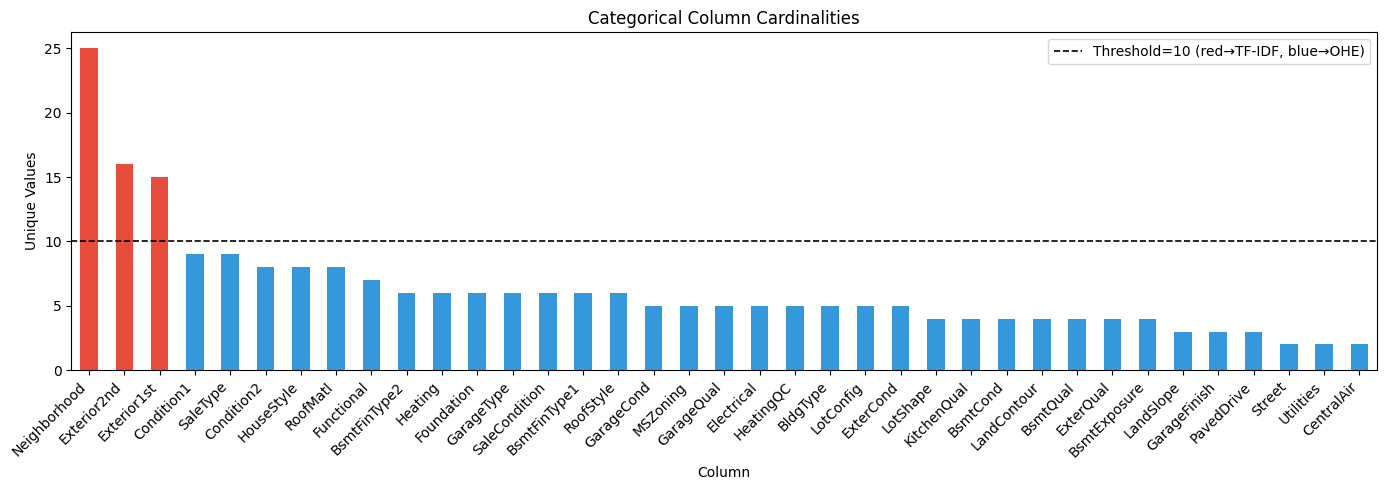

In [ ]:

cat_cols = df_train.select_dtypes(include='object').columns.tolist()
cardinalities = df_train[cat_cols].nunique().sort_values(ascending=False)

print("Cardinalities of categorical columns:")
print(cardinalities)

low_card_cols  = cardinalities[cardinalities < 10].index.tolist()
high_card_cols = cardinalities[cardinalities >= 10].index.tolist()

print(f"\nLow cardinality (<10)  → One-Hot Encoding  ({len(low_card_cols)} cols): {low_card_cols}")
print(f"High cardinality (≥10) → TF-IDF Encoding   ({len(high_card_cols)} cols): {high_card_cols}")

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v >= 10 else '#3498db' for v in cardinalities.values]
cardinalities.plot(kind='bar', ax=ax, color=colors)
ax.axhline(y=10, color='black', linestyle='--', linewidth=1.2, label='Threshold = 10')
ax.set_title('Categorical Column Cardinalities')
ax.set_xlabel('Column')
ax.set_ylabel('Unique Values')
ax.legend(['Threshold=10 (red→TF-IDF, blue→OHE)'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:

import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Recompute cardinalities on current (post-drop) columns ──────────
cat_cols_enc = df_train.select_dtypes(include='object').columns.tolist()
cardinalities_enc = df_train[cat_cols_enc].nunique()

low_card_cols  = cardinalities_enc[cardinalities_enc < 10].index.tolist()
high_card_cols = cardinalities_enc[cardinalities_enc >= 10].index.tolist()

print(f"OHE  (<10 card) → {len(low_card_cols)} cols : {low_card_cols}")
print(f"TFIDF(≥10 card) → {len(high_card_cols)} cols : {high_card_cols}")

# ── One-Hot Encoding for low-cardinality columns (< 10) ─────────────
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')
train_ohe = ohe.fit_transform(df_train[low_card_cols])
test_ohe  = ohe.transform(df_test[low_card_cols])
ohe_feature_names = ohe.get_feature_names_out(low_card_cols)

# ── TF-IDF Encoding for high-cardinality columns (≥ 10) ─────────────
tfidf_train_parts, tfidf_test_parts, tfidf_feat_names = [], [], []

for col in high_card_cols:
    vec = TfidfVectorizer(
        analyzer='word',
        token_pattern=r'(?u)\b\w+\b',
        max_features=15,
        sublinear_tf=True
    )
    train_vals = df_train[col].astype(str).values
    test_vals  = df_test[col].astype(str).values
    t_train = vec.fit_transform(train_vals)
    t_test  = vec.transform(test_vals)
    tfidf_train_parts.append(t_train)
    tfidf_test_parts.append(t_test)
    tfidf_feat_names += [f'tfidf_{col}__{v}' for v in vec.get_feature_names_out()]

train_tfidf = sp.hstack(tfidf_train_parts).toarray()
test_tfidf  = sp.hstack(tfidf_test_parts).toarray()

print(f"\nOHE  features  : {train_ohe.shape[1]}")
print(f"TFIDF features : {train_tfidf.shape[1]}")


OHE  (<10 card) → 34 cols : ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
TFIDF(≥10 card) → 3 cols : ['Neighborhood', 'Exterior1st', 'Exterior2nd']

OHE  features  : 171
TFIDF features : 45


In [ ]:

import warnings
warnings.filterwarnings('ignore')

def add_domain_features(df):
    df = df.copy()

    # ── Age / Time Features ──────────────────────────────────────────
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    df['RemodeledAge']   = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['GarageAge']      = df['YrSold'] - df['GarageYrBlt'] if 'GarageYrBlt' in df.columns else 0
    df['HouseAge2']      = df['HouseAge'] ** 2
    df['RemodeledAge2']  = df['RemodeledAge'] ** 2

    # ── Area Aggregation ─────────────────────────────────────────────
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF']   = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                            df['3SsnPorch']   + df['ScreenPorch'])
    df['TotalBathroom']  = (df['FullBath'] + 0.5 * df['HalfBath'] +
                            df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    df['LivAreaPerRoom'] = df['GrLivArea'] / (df['TotRmsAbvGrd'] + 1)
    df['GarageArea_x_Cars'] = df['GarageArea'] * df['GarageCars']
    df['BsmtFinRatio']   = df['BsmtFinSF1'] / (df['TotalBsmtSF'] + 1)
    df['2ndFlrRatio']    = df['2ndFlrSF']   / (df['TotalSF'] + 1)

    # ── Quality Interaction ──────────────────────────────────────────
    df['QualxCond']      = df['OverallQual'] * df['OverallCond']
    df['QualxArea']      = df['OverallQual'] * df['GrLivArea']
    df['QualxAge']       = df['OverallQual'] * (df['HouseAge'] + 1)
    df['GarageQualArea'] = df['GarageCars'] * df['GarageArea']

    # ── Log Transform (reduce skewness on key features) ─────────────
    for col in ['LotArea', 'GrLivArea', 'TotalSF', 'TotalBsmtSF',
                '1stFlrSF', 'LotFrontage']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    return df

df_train_fe = add_domain_features(df_train)
df_test_fe  = add_domain_features(df_test)

new_feats = [c for c in df_train_fe.columns if c not in df_train.columns and c != 'SalePrice']
print(f"New domain features created: {len(new_feats)}")
print(new_feats)


New domain features created: 22
['HouseAge', 'RemodeledAge', 'WasRemodeled', 'GarageAge', 'HouseAge2', 'RemodeledAge2', 'TotalSF', 'TotalPorchSF', 'TotalBathroom', 'LivAreaPerRoom', 'GarageArea_x_Cars', 'BsmtFinRatio', '2ndFlrRatio', 'QualxCond', 'QualxArea', 'QualxAge', 'GarageQualArea', 'log_LotArea', 'log_GrLivArea', 'log_TotalSF', 'log_TotalBsmtSF', 'log_1stFlrSF']


In [ ]:

from sklearn.preprocessing import StandardScaler

# ── Numeric feature matrix ───────────────────────────────────────────
num_cols_fe = df_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_fe = [c for c in num_cols_fe if c not in ['Id', 'SalePrice']]

# Re-run encoding on the FE-enriched dataframes (same schema, OHE/TFIDF already fitted)
train_ohe_fe = ohe.transform(df_train_fe[low_card_cols])
test_ohe_fe  = ohe.transform(df_test_fe[low_card_cols])

tfidf_train_parts_fe, tfidf_test_parts_fe = [], []
for col in high_card_cols:
    # Use same fitted vectorizer (stored implicitly in the loop above — rebuild)
    pass

# ── Rebuild TF-IDF with stored vectorizers ───────────────────────────
tfidf_vectorizers = {}
tfidf_train_parts2, tfidf_test_parts2, tfidf_feat_names2 = [], [], []

for col in high_card_cols:
    vec = TfidfVectorizer(
        analyzer='word',
        token_pattern=r'(?u)\b\w+\b',
        max_features=15,
        sublinear_tf=True
    )
    t_train = vec.fit_transform(df_train_fe[col].astype(str).values)
    t_test  = vec.transform(df_test_fe[col].astype(str).values)
    tfidf_train_parts2.append(t_train)
    tfidf_test_parts2.append(t_test)
    tfidf_feat_names2 += [f'tfidf_{col}__{v}' for v in vec.get_feature_names_out()]
    tfidf_vectorizers[col] = vec

train_tfidf_fe = sp.hstack(tfidf_train_parts2).toarray()
test_tfidf_fe  = sp.hstack(tfidf_test_parts2).toarray()

# ── Assemble full feature matrix ─────────────────────────────────────
X_num_train = df_train_fe[num_cols_fe].values
X_num_test  = df_test_fe[num_cols_fe].values

X_train_full = np.hstack([X_num_train, train_ohe_fe, train_tfidf_fe])
X_test_full  = np.hstack([X_num_test,  test_ohe_fe,  test_tfidf_fe])
y_train      = df_train_fe['SalePrice'].values

# ── Scale for TabPFN ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test_full)

print(f"X_train shape : {X_train_scaled.shape}")
print(f"X_test  shape : {X_test_scaled.shape}")
print(f"y_train shape : {y_train.shape}")


X_train shape : (1460, 273)
X_test  shape : (1459, 273)
y_train shape : (1460,)


Total features before selection : 273
  [VarianceThreshold] Dropped :   72  |  Remaining : 201
  [LGB Importance]    Dropped :   52  |  Remaining : 149

Final feature count after GIGO selection : 149


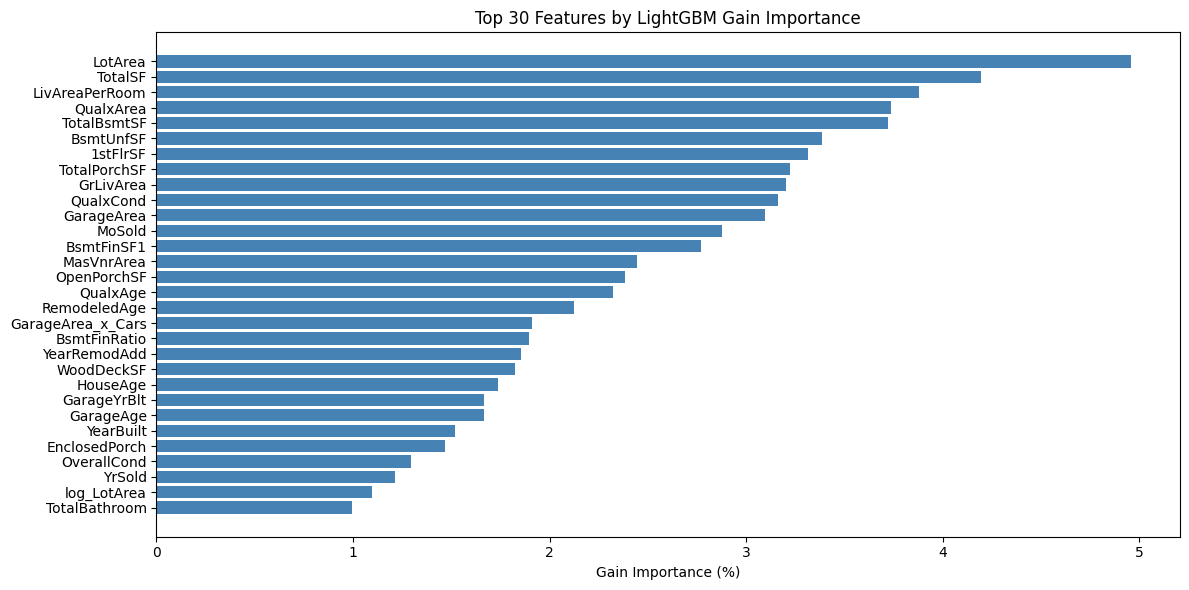


X_train_scaled shape : (1460, 149)
X_test_scaled  shape : (1459, 149)


In [ ]:

import lightgbm as lgb
from sklearn.feature_selection import VarianceThreshold

all_feat_names = (
    list(num_cols_fe) +
    list(ohe_feature_names) +
    tfidf_feat_names2
)
n_total = X_train_full.shape[1]
print(f"Total features before selection : {n_total}")

# Variance Threshold
#   Remove features with near-zero variance (constant/quasi-constant).
#   Threshold = 0.01 (feature must have std > ~0.1 across all samples).
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_train_full)
vt_mask = vt.get_support()

feat_names_vt = [all_feat_names[i] for i in range(n_total) if vt_mask[i]]
X_test_vt     = X_test_full[:, vt_mask]

dropped_vt = n_total - X_vt.shape[1]
print(f"  [VarianceThreshold] Dropped : {dropped_vt:>4d}  |  Remaining : {X_vt.shape[1]}")

# LightGBM Feature Importance
#   Train a fast LGB model on log-target and extract gain-based
#   importances. Drop features whose cumulative gain contribution
#   is below a threshold (keep features covering 99.5 % of total gain).

y_log_sel = np.log1p(y_train)

lgb_sel = lgb.LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_sel.fit(X_vt, y_log_sel)

importances = lgb_sel.feature_importances_          # gain-based
total_gain  = importances.sum()
sorted_idx  = np.argsort(importances)[::-1]         # descending

# Cumulative gain — keep features up to GAIN_COVER of total gain
GAIN_COVER = 0.995
cumulative  = np.cumsum(importances[sorted_idx]) / total_gain
n_keep      = int(np.searchsorted(cumulative, GAIN_COVER)) + 1
keep_idx    = sorted_idx[:n_keep]                   # indices into vt-filtered space
lgb_mask    = np.zeros(X_vt.shape[1], dtype=bool)
lgb_mask[keep_idx] = True

feat_names_sel = [feat_names_vt[i] for i in range(X_vt.shape[1]) if lgb_mask[i]]
X_train_sel    = X_vt[:, lgb_mask]
X_test_sel     = X_test_vt[:, lgb_mask]

dropped_lgb = X_vt.shape[1] - X_train_sel.shape[1]
print(f"  [LGB Importance]    Dropped : {dropped_lgb:>4d}  |  Remaining : {X_train_sel.shape[1]}")
print(f"\nFinal feature count after GIGO selection : {X_train_sel.shape[1]}")

# ── Feature importance bar chart (top-30) ────────────────────────────
top_n = 30
top_idx   = sorted_idx[:top_n]
top_names = [feat_names_vt[i] for i in top_idx]
top_imp   = importances[top_idx] / total_gain * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_names[::-1], top_imp[::-1], color='steelblue')
ax.set_xlabel('Gain Importance (%)')
ax.set_title(f'Top {top_n} Features by LightGBM Gain Importance')
plt.tight_layout()
plt.show()

# ── Re-scale the selected features ───────────────────────────────────
scaler_sel = StandardScaler()
X_train_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_scaled  = scaler_sel.transform(X_test_sel)

print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")


In [ ]:
!pip install tabpfn-client

In [ ]:
import os
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from tabpfn_client import set_access_token, TabPFNRegressor

# ── 1. Authenticate using TabPFN Client ─────────────────────────────
os.environ["TABPFN_TOKEN"] = "Your api key"
set_access_token("tabpfn_sk_50X_vxyZcvEjwlN04VrgUxm8XLGEfeM3EgJRVRim6RU")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ── 2. Log-transform target (SalePrice is right-skewed) ───────────────
y_log = np.log1p(y_train)

# ── 3. TabPFN Regressor (Fixed n_estimators <= 8 for API client) ──────
model = TabPFNRegressor(
    n_estimators=8,  # Maximum allowed by the API client service
)

# ── 4. Cross-validation ───────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(y_log))
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_log[train_idx], y_log[val_idx]

    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred

    rmse = root_mean_squared_error(y_val, val_pred)
    rmse_scores.append(rmse)
    print(f"  Fold {fold+1} | RMSLE: {rmse:.5f}")

print(f"\nMean RMSLE  : {np.mean(rmse_scores):.5f}")
print(f"Std  RMSLE  : {np.std(rmse_scores):.5f}")
print(f"OOF  RMSLE  : {root_mean_squared_error(y_log, oof_preds):.5f}")

  Fold 1 | RMSLE: 0.11825
  Fold 2 | RMSLE: 0.09816
  Fold 3 | RMSLE: 0.21241
  Fold 4 | RMSLE: 0.11483
  Fold 5 | RMSLE: 0.09858

Mean RMSLE  : 0.12845
Std  RMSLE  : 0.04277
OOF  RMSLE  : 0.13538


In [ ]:
import pandas as pd
import numpy as np

# Convert log-transformed test predictions back to original scale (if not already done)
test_preds = np.expm1(test_preds_log)

# Create submission dataframe using your existing df_test
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': test_preds
})

# Save as sample_submission.csv
submission.to_csv('sample_submission.csv', index=False)
print("sample_submission.csv successfully created and saved!")

sample_submission.csv successfully created and saved!
